In [1]:
# import necessary libraries and set random seed for reproducibility
import pandas as pd
import numpy as np
import random
import os
import pydotplus
import graphviz
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
seed = 42    # 42 is just an arbitrary number, you can use any integer you like

## Use Iris Dataset from Sklearn
I'm going to go through steps similar to the templated notebook, but instead of using mock data, I will use the Iris Dataset.


In [2]:
# Load directly as a pandas DataFrame

iris_bunch = load_iris(as_frame=True)

# Extract the completed DataFrame
df = iris_bunch.frame

# View the data
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Helper Functions

In [3]:
# create a helper function for data visualization
def visualize_data(df):
    # Plot distribution for each feature
    for i, col in enumerate(iris_bunch.feature_names):
        ax = axes[i//2, i%2]
        sns.boxplot(data=df, x='species_name', y=col, ax=ax, hue='species_name')
        ax.set_title(f'{col} Distribution by Species')
    plt.tight_layout()
    plt.show()
    # Pairplot colored by species
    # Look for features where one species is completely separated from the others
    sns.pairplot(df, vars=iris_bunch.feature_names, hue='species_name', palette='Set2', diag_kind='kde')
    plt.suptitle("Pairwise Relationships of Iris Features", y=1.02)
    plt.show()

    plt.figure(figsize=(8, 6))
    # Calculate correlation matrix only on numerical features
    corr_matrix = df[iris_bunch.feature_names].corr()
    
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Feature Correlation Matrix")
    plt.show()

In [4]:
# create helper function for visualizing decision tree
def tree_graph_to_png(tree, feature_names, target_names):
    tree_str = export_graphviz(
    tree, 
    out_file=None, 
    feature_names=feature_names,  
    class_names=target_names,  
    filled=True, 
    rounded=True,  
    special_characters=True
)  

    graph = graphviz.Source(tree_str)  
    graph.render("iris_decision_tree")  # Saves as 'iris_decision_tree.pdf'
    graph.view()  

In [5]:
# helper function to evaluate model and visualize confusion matrix
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    # Calculate overall accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Model Accuracy on Test Data: {accuracy * 100:.2f}%\n")
    
    # Print detailed precision, recall, and f1-score for each flower species
    print("--- Detailed Classification Report ---")
    print(classification_report(y_test, y_pred, target_names=iris_bunch.target_names))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="Blues", 
        xticklabels=iris_bunch.target_names, 
        yticklabels=iris_bunch.target_names
    )
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

## Data Exploration 

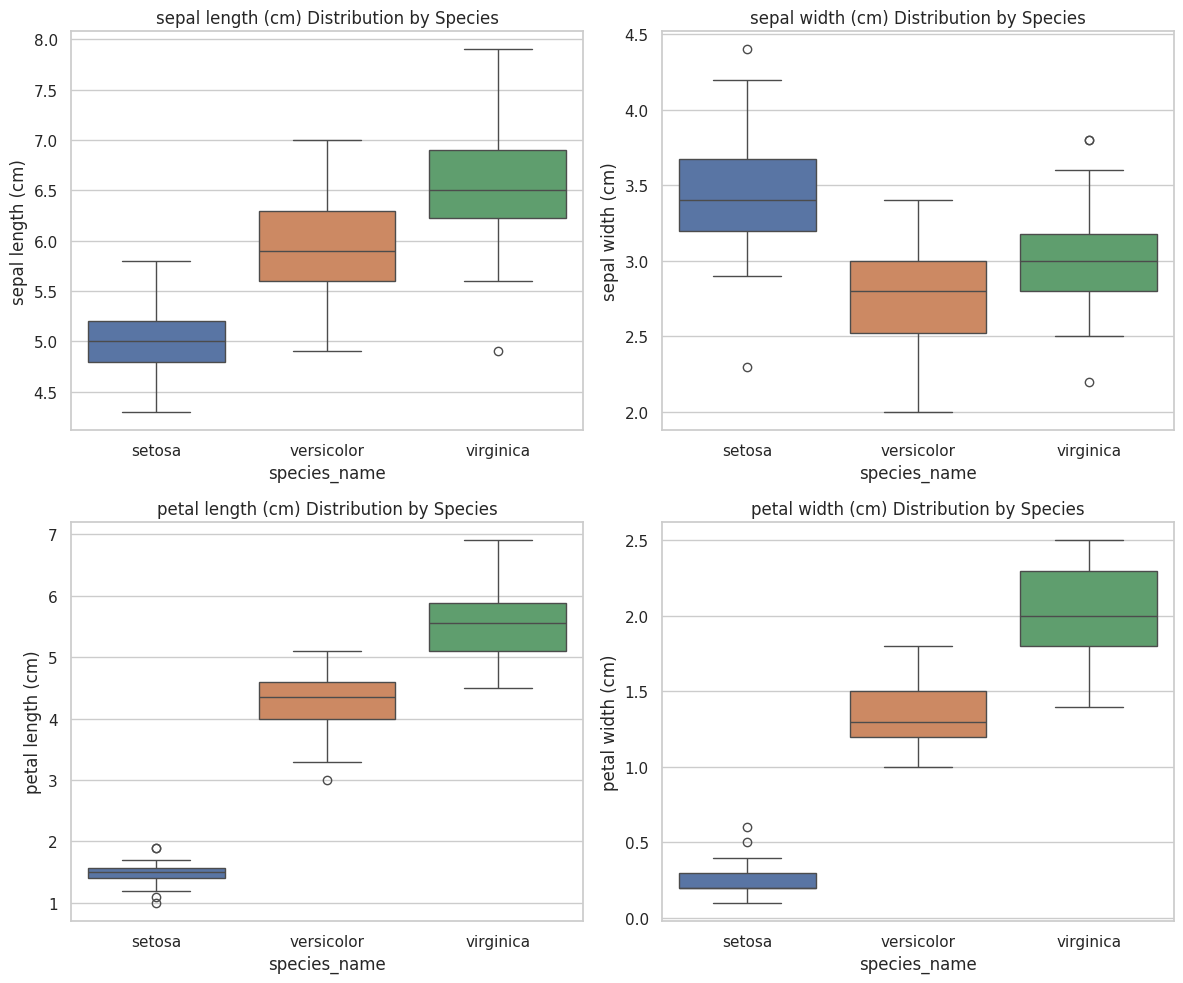

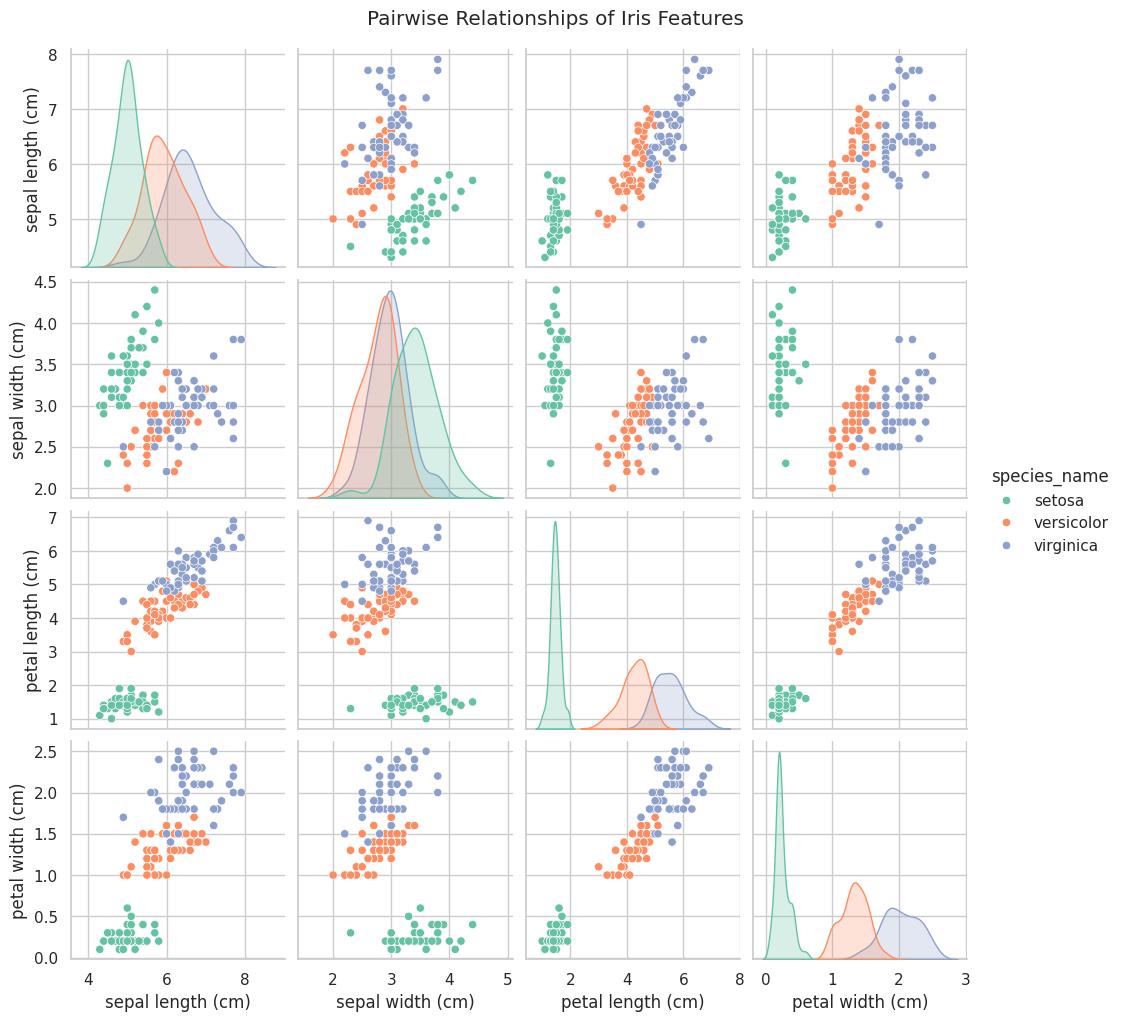

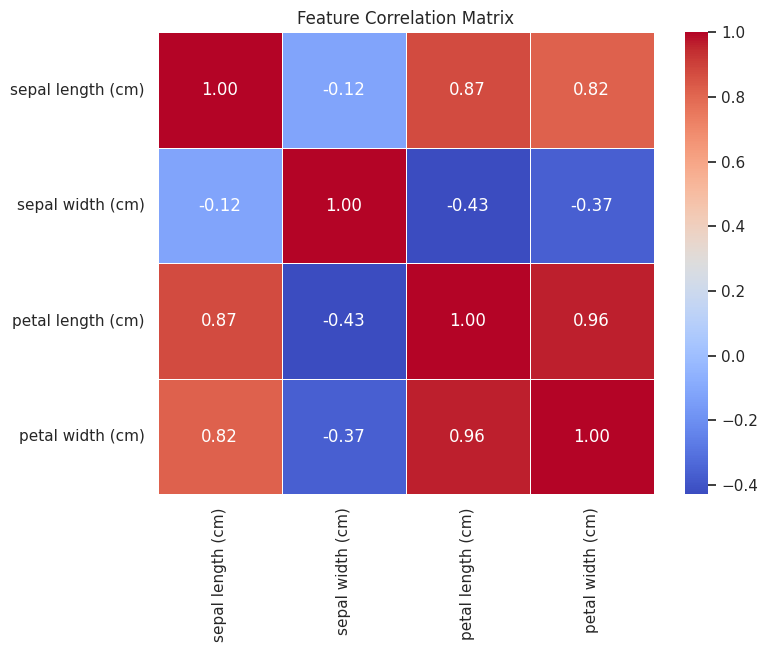

In [6]:
# Map numerical targets to actual names for better visualization text

df['species_name'] = df['target'].map({i: name for i, name in enumerate(iris_bunch.target_names)})

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
visualize_data(df)



## Train - Test Split

In [7]:

# 1. Separate features (X) and target label (y)
X = df[iris_bunch.feature_names]
y = df['target']

# 2. Split into 80% train and 20% test
# stratify ensures each set gets exactly 33% of each iris species
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


Training set shape: (120, 4)
Testing set shape: (30, 4)


## Train tree and get predictions

In [8]:
#define Decision Tree
dt = DecisionTreeClassifier(
    criterion = 'entropy', 
    max_depth=3,
    min_samples_split=4,    
    random_state=seed  )

dt.fit(X_train, y_train)

tree_graph_to_png(dt, feature_names=iris_bunch.feature_names, target_names=iris_bunch.target_names)

Entropy measures the impurity or uncertainty present in the data. 

$$
\mathcal{H}(S) = - \sum_{i=1}^N p_i \log_2 p_i
$$

where 
- $S$ is the set of instances
- $N$ is the sample size
- $p_i$ is event probability

## Make Predictions and Measure Performance

Model Accuracy on Test Data: 96.67%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



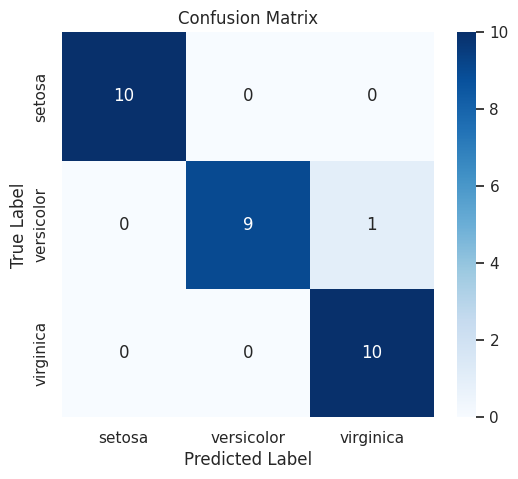

In [9]:
evaluate_model(dt, X_test, y_test)

In [10]:
scores = cross_val_score(dt, X, y, cv=5)
print(f"All CV Scores: {scores}")
print(f"Average CV Accuracy: {scores.mean() * 100:.2f}%")

All CV Scores: [0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
Average CV Accuracy: 96.00%


## Additional Steps
I'm going to add a few more steps in here to go further:
- **Hyperparameter Tuning:** Instead of guessing values for parameters like max_depth, you can use GridSearchCV to automatically test    multiple combinations and choose the absolute best settings.
- **Cross Validation:** Evaluating your model on just one test split can lead to luck-based results (good or bad). K-Fold cross-validation splits your data multiple different ways and averages the score to give you the true, robust accuracy.
- **Check Feature Importance:** Decision trees calculate exactly which features contribute the most to making correct predictions. If you have features with zero importance, removing them can simplify your model and reduce noise.



In [11]:
from sklearn.model_selection import GridSearchCV

# Define a grid of parameters to test
param_grid = {
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_split': [2, 3, 4],
    'criterion': ['gini', 'entropy']
}

# Run the grid search with 5-fold cross-validation
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Get the optimized model
best_model = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")


Best parameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 2}


Model Accuracy on Test Data: 93.33%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



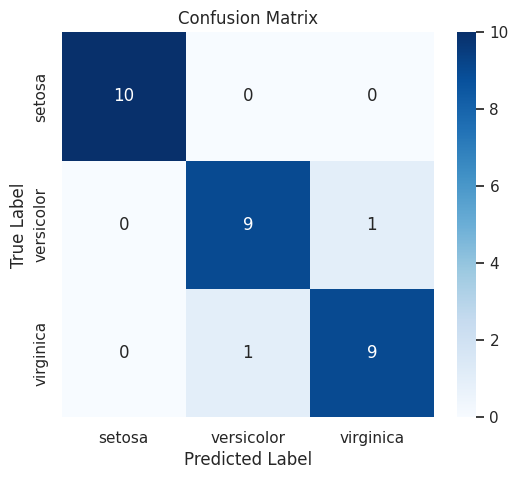

All CV Scores: [0.96666667 0.96666667 0.9        0.93333333 1.        ]
Average CV Accuracy: 95.33%


In [12]:
evaluate_model(best_model, X_test, y_test)
# Run 5-fold cross-validation on the whole dataset
scores = cross_val_score(best_model, X, y, cv=5)
print(f"All CV Scores: {scores}")
print(f"Average CV Accuracy: {scores.mean() * 100:.2f}%")

Interestingly, our gridsearch actually decreased the accuracy of the model. So now when we look at the feature importance in the next part, we will use the original model.

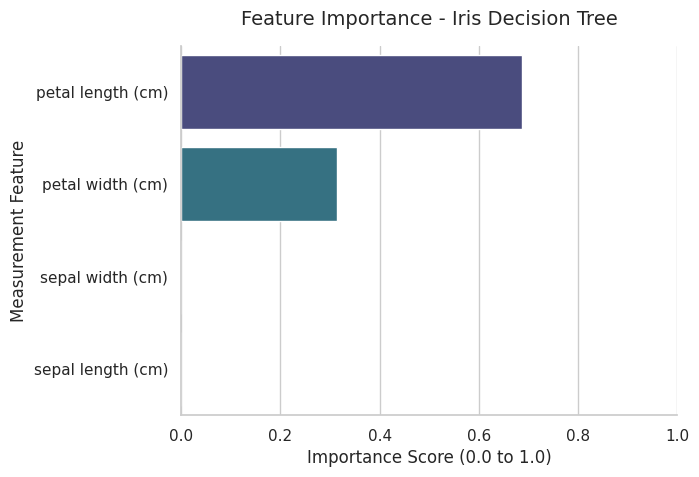

In [13]:
# Create a DataFrame of feature importances
importance_df = pd.DataFrame({
    'Feature': iris_bunch.feature_names,
    'Importance': dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df,
    palette="viridis",
    hue="Feature",
    legend=False,
)

# 5. Add clear labels, title, and a clean grid layout
plt.title("Feature Importance - Iris Decision Tree", fontsize=14, pad=15)
plt.xlabel("Importance Score (0.0 to 1.0)", fontsize=12)
plt.ylabel("Measurement Feature", fontsize=12)
plt.xlim(0, 1.0)  # Total importance across all features always equals 1.0
sns.despine()  # Removes the unnecessary top and right borders

# 6. Display the graphic
plt.show()


It's worth noting that only the petal length and width were features used in the model. This means we can drop the other features and we should get the same results. I'll leave them for now because this is a basic example, but when we're dealing with larger datasets, this would be important to note so we can cut down on unnecessary features.